In [1]:
# -------------------------------
# Imports
# -------------------------------
import numpy as np
import pandas as pd
import optuna
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
import time
import gc
import warnings
warnings.filterwarnings('ignore')



# from sklearnex import patch_sklearn
# patch_sklearn()  # patches scikit-learn algorithms
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()
# -------------------------------


# ------------------- IMPORT SRC ------------------------------------
# src is the parent folder of notebooks, so we need to add it to sys.path to import config and utils
import os
import sys
notebook_dir = os.getcwd() 

# Parent folder of src
project_root = os.path.abspath(os.path.join(notebook_dir, "..")) 
sys.path.append(project_root)

print("sys.path contains:", sys.path[-1])

from src.config import Config as Config  
from src.data_loader import load_data, prepare_data

cfg = Config

KAGGLE_EVAL = cfg.KAGGLE_EVAL
RANDOM_STATE = cfg.RANDOM_STATE
TASK = cfg.TASK
USE_POSTPROCESSING = cfg.USE_POSTPROCESSING
TARGET = cfg.TARGET
ID = cfg.ID
SUB_PATH = cfg.SUB_PATH
SUBMIT_PROBABILITIES = cfg.SUBMIT_PROBABILITIES
metric_name = cfg.LIB_PARAMS["histgb"]["metric"]


from src.data_loader import load_data, prepare_data
from src.optuna_utils import run_optuna
from src.evaluation_utils import evaluate_model, evaluate_metric
from src.visualization_utils import plot_feature_importance, plot_learning_curve, shap_summary
from src.postprocessing_utils import optimize_postprocessing, apply_postprocessing
from src.data_splitter import DataSplitter
from src.experiment_tracker import ExperimentTracker
from sklearn.utils import compute_class_weight

# -------------------------------------------------------


# -------------------------------
# Load & prepare data
# -------------------------------
X_train, X_test, y_train, y_test = load_data("encoded")
X_train, X_test, y_train_numeric, y_test_numeric, test_ids, num_classes, int_to_label = prepare_data(
    X_train, X_test, y_train, y_test, target=cfg.TARGET, drop_id=True
)

y_train_numeric = np.array(y_train_numeric)
y_test_numeric = np.array(y_test_numeric) if y_test_numeric is not None else None



sys.path contains: /home/ismail/x42
Number of classes: 2
X_train shape: (300000, 116)
X_test shape: (200000, 116)
y_train shape: (300000,)
y_test labels are not available


Original: (15000, 116)
Sample: (15000, 116)


In [3]:
# -------------------------------
# Data splitter
# -------------------------------
splitter = DataSplitter(
    method="stratified_kfold",
    n_splits=5,
    random_state=RANDOM_STATE,
    folds_path="data/folds.npy"
)
folds = list(splitter.split(X_train, y_train_numeric, reuse_folds=False, verbose=True))

✅ Generated 5 folds for current dataset
--- Splitting data ---
Method: stratified_kfold
Number of splits: 5
Random seeds: [42]
Dataset size: 15000
Total folds: 5

Fold 0: Train size=12000, Val size=3000
Fold 1: Train size=12000, Val size=3000
Fold 2: Train size=12000, Val size=3000
Fold 3: Train size=12000, Val size=3000
Fold 4: Train size=12000, Val size=3000


# ADABOOST

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import optuna
import gc

num_classes = len(np.unique(y_train_numeric))
print(f"Number of classes: {num_classes}")

# -------------------------------
# Optuna objective function
# -------------------------------
def objective(trial):

    # -------------------------------
    # Hyperparameter search space
    # -------------------------------
    # n_estimators is the AdaBoost equivalent of max_iter
    # n_estimators = trial.suggest_int('n_estimators', 50, getattr(cfg, "NUM_BOOST_ROUND", 500))
    n_estimators = trial.suggest_int('n_estimators', 50, 200)  # instead of 500
    learning_rate = trial.suggest_float('learning_rate', 1e-3, 1.0, log=True)
    
    # Base estimator parameters (Decision Tree)
    max_depth = trial.suggest_int("max_depth", 1, 5)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)

    param = {
        "n_estimators": n_estimators,
        "learning_rate": learning_rate,
        "random_state": getattr(cfg, "RANDOM_STATE", 42),
        "algorithm":  "SAMME"#  "SAMME", # Standard for modern sklearn / multiclass
    }
    
    # Decision tree params
    tree_params = {
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "random_state": getattr(cfg, "RANDOM_STATE", 42),
    }
    if cfg.TASK.lower() == "binary":
        if getattr(cfg, "IS_UNBALANCE", True):
                # Calculate balanced weights: n_samples / (n_classes * np.bincount(y))
            weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train_numeric)
            cw_dict = {0: weights[0], 1: weights[1]}
        else:
            cw_dict = {0: 1, 1: 1}
        oof_preds = np.zeros(len(y_train_numeric))
    else:
        oof_preds = np.zeros((len(y_train_numeric), num_classes))
                    # Multiclass logic
        classes = np.unique(y_train_numeric)
        weights = compute_class_weight("balanced", classes=classes, y=y_train_numeric)
        cw_dict = {c: w for c, w in zip(classes, weights)}


    # -------------------------------
    # Stratified folds
    # -------------------------------
    fold_results = []

    for n_fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train_numeric[train_idx], y_train_numeric[valid_idx]

            # -------------------------------
        # Class weights / Sample weights
        # -------------------------------
        if len(set(cw_dict.values())) == 1:
            sample_weight = None
        else:
            sample_weight = np.array([cw_dict[y] for y in y_tr])

        # AdaBoost wraps the DecisionTree
        base_tree = DecisionTreeClassifier(**tree_params)
        model = AdaBoostClassifier(
            estimator=base_tree,
            **param
        )

        model.fit(X_tr, y_tr, sample_weight=sample_weight)
        # -------------------------------
        # Predictions for OOF
        # -------------------------------
        pred_val = model.predict_proba(X_val)

        if cfg.TASK.lower() == "binary":
            oof_preds[valid_idx] = pred_val[:, 1]
        else:
            oof_preds[valid_idx] = pred_val

        # -------------------------------
        # Evaluate fold
        # -------------------------------
        if cfg.MAXIMIZE_METRIC:
            if cfg.TASK.lower() == "binary":
                fold_score = roc_auc_score(y_val, pred_val[:, 1])
            else:
                fold_score = roc_auc_score(y_val, pred_val, multi_class="ovr")
        else:
            fold_score = log_loss(y_val, pred_val)

        # AdaBoost doesn't have a dynamic n_iter_ attribute like HistGB, 
        # it just uses n_estimators.
        fold_results.append((n_fold, fold_score, model.n_estimators))
        trial.report(fold_score, step=n_fold)

        if trial.should_prune():
            raise optuna.TrialPruned()

        del model, X_tr, X_val, y_tr, y_val, pred_val
        if len(X_train) > getattr(cfg, "LARGE_DATASET_THRESHOLD", 500_000):
            gc.collect()

    gc.collect()

    # -------------------------------
    # True OOF score
    # -------------------------------
    if cfg.MAXIMIZE_METRIC:
        if cfg.TASK.lower() == "binary":
            mean_score = roc_auc_score(y_train_numeric, oof_preds)
        else:
            mean_score = roc_auc_score(y_train_numeric, oof_preds, multi_class="ovr")
    else:
        if cfg.TASK.lower() == "binary":
            oof_probs = np.column_stack([1 - oof_preds, oof_preds])
        else:
            oof_probs = oof_preds
        mean_score = log_loss(y_train_numeric, oof_probs)

    best_iter = int(np.round(np.mean([f[2] for f in fold_results])))

    # -------------------------------
    # Fold report
    # -------------------------------
    metric_label = "AUC" if cfg.MAXIMIZE_METRIC else "LogLoss"
    print("\n" + "*" * 50)
    for fold, score, iter_ in fold_results:
        print(f"Fold {fold:>2d} | {metric_label}: {score:.5f} | Estimators: {iter_:>5d}")
    std_score = np.std([s for _, s, _ in fold_results])
    print(f"\nMean {metric_label}: {mean_score:.5f} ± {std_score:.5f}")
    print("*" * 50 + "\n")

    # -------------------------------
    # Store trial info
    # -------------------------------
    trial.set_user_attr("fold_results", fold_results)
    trial.set_user_attr("best_iteration", best_iter)
    trial.set_user_attr("mean_score", mean_score)
    trial.set_user_attr("params", param)
    trial.set_user_attr("tree_params", tree_params) # Saved tree params too
    trial.set_user_attr("oof_preds", oof_preds)

    return mean_score


OOF auc: 0.78833


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. U

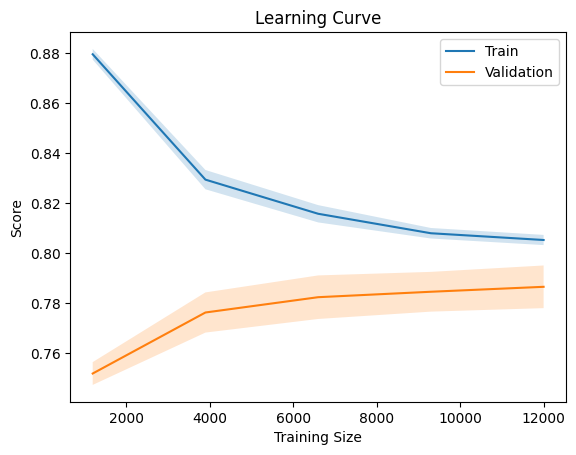

Saved model → /home/ismail/x42/outputs/experiments/20260422-014342_adaboost_CVScore0.7883_exp_20260422-0143_learning_rate0.3577789555578892_max_depth1/model.pkl
Saved params → /home/ismail/x42/outputs/experiments/20260422-014342_adaboost_CVScore0.7883_exp_20260422-0143_learning_rate0.3577789555578892_max_depth1/params.json
Saved metrics → /home/ismail/x42/outputs/experiments/20260422-014342_adaboost_CVScore0.7883_exp_20260422-0143_learning_rate0.3577789555578892_max_depth1/metrics.json
Saved training time → /home/ismail/x42/outputs/experiments/20260422-014342_adaboost_CVScore0.7883_exp_20260422-0143_learning_rate0.3577789555578892_max_depth1/training_time.txt
Saved metadata → /home/ismail/x42/outputs/experiments/20260422-014342_adaboost_CVScore0.7883_exp_20260422-0143_learning_rate0.3577789555578892_max_depth1/metadata.json
Updated experiments summary → /home/ismail/x42/outputs/experiments/experiments_summary.csv
Saved train predictions to /home/ismail/x42/outputs/experiments/20260422-

5146

In [ ]:

import time
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
import numpy as np
import gc

# -------------------------------
# Run Optuna optimization
# -------------------------------
start = time.time()
study = run_optuna(objective, cfg)  # param: use_medianPruner
train_time = time.time() - start

oof_preds = study.best_trial.user_attrs['oof_preds']

# -------------------------------
# Train final AdaBoostClassifier on full training data
# -------------------------------
best_params = study.best_params.copy()
# Extracting nested tree params from user_attrs
final_tree_params = study.best_trial.user_attrs["tree_params"]

print("\nTraining final model on full training data...")

final_base_estimator = DecisionTreeClassifier(**final_tree_params)
final_model = AdaBoostClassifier(
    estimator=final_base_estimator,
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    random_state=getattr(cfg, "RANDOM_STATE", 42),
    algorithm="SAMME"
)
final_model.fit(X_train, y_train_numeric)

# if ur optimizing for log_loss
# from sklearn.calibration import CalibratedClassifierCV

# cal_model = CalibratedClassifierCV(
#     final_model,
#     method="isotonic",  # or "sigmoid"
#     cv=5
# )
# cal_model.fit(X_train, y_train_numeric)

# -------------------------------
# Evaluate on training set
# -------------------------------
print("---------------- Train Set --------------------")
pred_train_proba = final_model.predict_proba(X_train)



# ----------------------------
# FIX: binary vs multiclass handling
# -------------------------------
if cfg.TASK.lower() == "binary":
    y_score_train = pred_train_proba[:, 1]   # FIX: take positive class only
    y_pred_train_class = (y_score_train >= 0.5).astype(int)
else:
    y_score_train = pred_train_proba
    y_pred_train_class = pred_train_proba.argmax(axis=1)

metrics_df, _ = evaluate_model(
    y_train_numeric,
    y_score_train,   # FIX: pass correct shape
    task=cfg.TASK
)
print(metrics_df)
print("Best mean CV score across all trials:", study.best_value)

# ... [The rest of your evaluation/plotting/tracking code remains identical] ...

# Evaluate OOF
if cfg.TASK.lower() == "binary":
    oof_pred_class = (oof_preds >= 0.5).astype(int)
else:
    oof_pred_class = np.argmax(oof_preds, axis=1)

oof_score = evaluate_metric(
    y_true=y_train_numeric,
    y_input=oof_preds,  # probabilities
    task=TASK,
    kaggle_eval=KAGGLE_EVAL
)
print(f"OOF {KAGGLE_EVAL}: {oof_score:.5f}")



from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, valid_scores = learning_curve(
    estimator=final_model,
    X=X_train,
    y=y_train_numeric,
    cv=5,
    scoring="roc_auc" if cfg.TASK.lower() == "binary" else "neg_log_loss",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

# Fix sign if log loss
if cfg.TASK.lower() != "binary":
    train_mean = -train_mean
    valid_mean = -valid_mean

plt.plot(train_sizes, train_mean, label="Train")
plt.plot(train_sizes, valid_mean, label="Validation")
plt.xlabel("Training Size")
plt.ylabel("Score")
plt.legend()
plt.title("Learning Curve")
train_std = train_scores.std(axis=1)
valid_std = valid_scores.std(axis=1)

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.2)
plt.show()



# -------------------------------
# Optional post-processing
# -------------------------------
postprocessing_params = {}
if USE_POSTPROCESSING:
    pp_seeds = [RANDOM_STATE, 2026, 1234, 9999]
    pp_best_params, pp_best_seed, pp_best_score = optimize_postprocessing(
        oof_preds,
        y_train_numeric,
        task=TASK,
        kaggle_eval=KAGGLE_EVAL,
        n_trials=100,
        seeds=pp_seeds
    )

    oof_pred_opt = apply_postprocessing(oof_preds, pp_best_params, task=TASK, return_proba=True)
    oof_pred_class_opt = apply_postprocessing(oof_preds, pp_best_params, task=TASK)
    oof_acc_opt = evaluate_metric(
        y_true=y_train_numeric,
        y_input=oof_pred_opt,
        task=TASK,
        kaggle_eval=KAGGLE_EVAL
    )

    print(f"OOF {KAGGLE_EVAL} after post-processing: {oof_acc_opt:.5f}")
    postprocessing_params = {
        "best_params": pp_best_params,
        "best_seed": pp_best_seed,
        "best_score": pp_best_score,
        "oof_pred_class_opt": oof_pred_class_opt,
        "oof_pred_opt": oof_pred_opt,
        "oof_acc_opt": oof_acc_opt,
        "kaggle_eval": KAGGLE_EVAL
    }

# -------------------------------
# Evaluate on test set
# -------------------------------
pred_test = final_model.predict_proba(X_test)
y_pred_class = (pred_test >= 0.5).astype(int) if cfg.TASK.lower() == "binary" else pred_test.argmax(axis=1)

if X_test is not None and y_test is not None:
    roc_auc_test = roc_auc_score(y_test, pred_test[:, 1]) if cfg.TASK.lower() == "binary" else roc_auc_score(y_test, pred_test, multi_class='ovr')
    logloss_test = log_loss(y_test, pred_test)
    accuracy_test = accuracy_score(y_test, y_pred_class)

    print("\n--- Test set performance ---")
    print(f"Test ROC AUC: {roc_auc_test:.5f}")
    print(f"Test Log Loss: {logloss_test:.5f}")
    print(f"Test Accuracy: {accuracy_test:.5f}")

# -------------------------------
# Experiment Tracking
# -------------------------------
from src.experiment_tracker import ExperimentTracker
tracker = ExperimentTracker()
exp_dir = tracker.run_experiment(
    model_name="adaboost",
    final_model=final_model,
    X_train=X_train,
    y_train=y_train_numeric,
    X_test=X_test,
    best_params=best_params,
    best_score=study.best_value,
    metrics_df=metrics_df,
    train_time=train_time,
    oof_preds=oof_preds,
    task=TASK,
    postprocessing_params=postprocessing_params,
    use_postprocessing=USE_POSTPROCESSING,
    test_ids=test_ids,
    id_col=ID,
    target_col=TARGET,
    int_to_label=int_to_label,
    sample_submission_path=SUB_PATH,
    submit_proba=SUBMIT_PROBABILITIES
)
gc.collect()

**✅ If you're optimizing log_loss**

**🧠 Optional (but actually important for Kaggle)**
```python
from sklearn.calibration import CalibratedClassifierCV

final_model = CalibratedClassifierCV(final_model, method="isotonic", cv=5)
final_model.fit(X_train, y_train_numeric)
```

👉 This is HUGE for:

- log_loss
- leaderboard ranking

AdaBoost probabilities are not well calibrated by default

👉 If you want perfect pipeline:

You should ideally:

calibrate inside CV (OOF level)

# BaggingClassifier

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import optuna
import gc

num_classes = len(np.unique(y_train_numeric))
print(f"Number of classes: {num_classes}")

# -------------------------------
# Optuna objective function
# -------------------------------
def objective(trial):

    # -------------------------------
    # Hyperparameter search space
    # -------------------------------
    n_estimators = trial.suggest_int('n_estimators', 10, 500)
    max_samples = trial.suggest_float('max_samples', 0.5, 1.0)
    max_features = trial.suggest_float('max_features', 0.5, 1.0)
    bootstrap = trial.suggest_categorical("bootstrap", [True, False])

    # Base estimator parameters (Decision Tree)
    max_depth = trial.suggest_int("max_depth", 3, 15)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 50)
    # min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    # criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])

    param = {
        "n_estimators": n_estimators,
        "max_samples": max_samples,
        "max_features": max_features,
        "bootstrap":bootstrap,
        "random_state": getattr(cfg, "RANDOM_STATE", 42),
        "n_jobs": -1, # Bagging is easily parallelized
    }
    
    tree_params = {
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        # "min_samples_split":min_samples_split,
#       "criterion":criterion,
        "random_state": getattr(cfg, "RANDOM_STATE", 42),
    }

    # -------------------------------
    # Class weights
    # -------------------------------
    # BaggingClassifier doesn't take sample_weight in .fit() directly in older versions,
    # so we apply class_weight directly to the base DecisionTree.
    if cfg.TASK.lower() == "binary":
        class_weight = "balanced" if getattr(cfg, "IS_UNBALANCE", True) else None
        oof_preds = np.zeros(len(y_train_numeric))
    else:
        classes = np.unique(y_train_numeric)
        weights = compute_class_weight("balanced", classes=classes, y=y_train_numeric)
        class_weight = {c: w for c, w in zip(classes, weights)}
        oof_preds = np.zeros((len(y_train_numeric), num_classes))

    tree_params["class_weight"] = class_weight

    # -------------------------------
    # Stratified folds
    # -------------------------------
    fold_results = []

    for n_fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train_numeric[train_idx], y_train_numeric[valid_idx]

        # Bagging wraps the DecisionTree
        base_tree = DecisionTreeClassifier(**tree_params)
        model = BaggingClassifier(
            estimator=base_tree,
            **param
        )

        model.fit(X_tr, y_tr)

        # -------------------------------
        # Predictions for OOF
        # -------------------------------
        pred_val = model.predict_proba(X_val)

        if cfg.TASK.lower() == "binary":
            oof_preds[valid_idx] = pred_val[:, 1]
        else:
            oof_preds[valid_idx] = pred_val

        # -------------------------------
        # Evaluate fold
        # -------------------------------
        if cfg.MAXIMIZE_METRIC:
            if cfg.TASK.lower() == "binary":
                fold_score = roc_auc_score(y_val, pred_val[:, 1])
            else:
                fold_score = roc_auc_score(y_val, pred_val, multi_class="ovr")
        else:
            fold_score = log_loss(y_val, pred_val)

        # Bagging doesn't "iterate" like Boosting, so we report n_estimators
        fold_results.append((n_fold, fold_score, model.n_estimators))
        trial.report(fold_score, step=n_fold)

        if trial.should_prune():
            raise optuna.TrialPruned()

        del model, X_tr, X_val, y_tr, y_val, pred_val
        if len(X_train) > getattr(cfg, "LARGE_DATASET_THRESHOLD", 500_000):
            gc.collect()

    gc.collect()

    # -------------------------------
    # True OOF score
    # -------------------------------
    if cfg.MAXIMIZE_METRIC:
        if cfg.TASK.lower() == "binary":
            mean_score = roc_auc_score(y_train_numeric, oof_preds)
        else:
            mean_score = roc_auc_score(y_train_numeric, oof_preds, multi_class="ovr")
    else:
        if cfg.TASK.lower() == "binary":
            oof_probs = np.column_stack([1 - oof_preds, oof_preds])
        else:
            oof_probs = oof_preds
        mean_score = log_loss(y_train_numeric, oof_probs)

    best_iter = int(np.round(np.mean([f[2] for f in fold_results])))

    # -------------------------------
    # Fold report
    # -------------------------------
    metric_label = "AUC" if cfg.MAXIMIZE_METRIC else "LogLoss"
    print("\n" + "*" * 50)
    for fold, score, iter_ in fold_results:
        print(f"Fold {fold:>2d} | {metric_label}: {score:.5f} | Estimators: {iter_:>5d}")
    std_score = np.std([s for _, s, _ in fold_results])
    print(f"\nMean {metric_label}: {mean_score:.5f} ± {std_score:.5f}")
    print("*" * 50 + "\n")

    # -------------------------------
    # Store trial info
    # -------------------------------
    trial.set_user_attr("fold_results", fold_results)
    trial.set_user_attr("best_iteration", best_iter)
    trial.set_user_attr("mean_score", mean_score)
    trial.set_user_attr("params", param)
    trial.set_user_attr("tree_params", tree_params)
    trial.set_user_attr("oof_preds", oof_preds)

    return mean_score


In [ ]:


import time
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
import numpy as np
import gc

# -------------------------------
# Run Optuna optimization
# -------------------------------
start = time.time()
study = run_optuna(objective, cfg, use_median_pruner=False, warmup_steps=2) 
train_time = time.time() - start

oof_preds = study.best_trial.user_attrs['oof_preds']

# -------------------------------
# Train final BaggingClassifier on full training data
# -------------------------------
best_params = study.best_params.copy()
final_tree_params = study.best_trial.user_attrs["tree_params"]

print("\nTraining final model on full training data...")

final_base_estimator = DecisionTreeClassifier(**final_tree_params)
final_model = BaggingClassifier(
    estimator=final_base_estimator,
    n_estimators=best_params['n_estimators'],
    max_samples=best_params['max_samples'],
    max_features=best_params['max_features'],
    random_state=getattr(cfg, "RANDOM_STATE", 42),
    n_jobs=-1
)
final_model.fit(X_train, y_train_numeric)

# -------------------------------
# Evaluate on training set
# -------------------------------
print("---------------- Train Set --------------------")
pred_train_proba = final_model.predict_proba(X_train)




if cfg.TASK.lower() == "binary":
    y_score_train = pred_train_proba[:, 1]   # FIX: take positive class only
    y_pred_train_class = (y_score_train >= 0.5).astype(int)
else:
    y_score_train = pred_train_proba
    y_pred_train_class = pred_train_proba.argmax(axis=1)

metrics_df, _ = evaluate_model(
    y_train_numeric,
    y_score_train,   # FIX: pass correct shape
    task=cfg.TASK
)

print(metrics_df)
print("Best mean CV score across all trials:", study.best_value)

# Evaluate OOF
if cfg.TASK.lower() == "binary":
    oof_pred_class = (oof_preds >= 0.5).astype(int)
else:
    oof_pred_class = np.argmax(oof_preds, axis=1)

oof_score = evaluate_metric(
    y_true=y_train_numeric,
    y_input=oof_preds,  # probabilities
    task=TASK,
    kaggle_eval=KAGGLE_EVAL
)
print(f"OOF {KAGGLE_EVAL}: {oof_score:.5f}")



# from sklearn.model_selection import learning_curve
# import numpy as np
# import matplotlib.pyplot as plt

# train_sizes, train_scores, valid_scores = learning_curve(
#     estimator=final_model,
#     X=X_train,
#     y=y_train_numeric,
#     cv=5,
#     scoring="roc_auc" if cfg.TASK.lower() == "binary" else "neg_log_loss",
#     train_sizes=np.linspace(0.1, 1.0, 5),
#     n_jobs=-1
# )

# train_mean = train_scores.mean(axis=1)
# valid_mean = valid_scores.mean(axis=1)

# # Fix sign if log loss
# if cfg.TASK.lower() != "binary":
#     train_mean = -train_mean
#     valid_mean = -valid_mean

# plt.plot(train_sizes, train_mean, label="Train")
# plt.plot(train_sizes, valid_mean, label="Validation")
# plt.xlabel("Training Size")
# plt.ylabel("Score")
# plt.legend()
# plt.title("Learning Curve")
# train_std = train_scores.std(axis=1)
# valid_std = valid_scores.std(axis=1)

# plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
# plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.2)
# plt.show()



# -------------------------------
# Optional post-processing
# -------------------------------
postprocessing_params = {}
if USE_POSTPROCESSING:
    pp_seeds = [RANDOM_STATE, 2026, 1234, 9999]
    pp_best_params, pp_best_seed, pp_best_score = optimize_postprocessing(
        oof_preds,
        y_train_numeric,
        task=TASK,
        kaggle_eval=KAGGLE_EVAL,
        n_trials=100,
        seeds=pp_seeds
    )

    oof_pred_opt = apply_postprocessing(oof_preds, pp_best_params, task=TASK, return_proba=True)
    oof_pred_class_opt = apply_postprocessing(oof_preds, pp_best_params, task=TASK)
    oof_acc_opt = evaluate_metric(
        y_true=y_train_numeric,
        y_input=oof_pred_opt,
        task=TASK,
        kaggle_eval=KAGGLE_EVAL
    )

    print(f"OOF {KAGGLE_EVAL} after post-processing: {oof_acc_opt:.5f}")
    postprocessing_params = {
        "best_params": pp_best_params,
        "best_seed": pp_best_seed,
        "best_score": pp_best_score,
        "oof_pred_class_opt": oof_pred_class_opt,
        "oof_pred_opt": oof_pred_opt,
        "oof_acc_opt": oof_acc_opt,
        "kaggle_eval": KAGGLE_EVAL
    }

# -------------------------------
# Evaluate on test set
# -------------------------------
pred_test = final_model.predict_proba(X_test)
y_pred_class = (pred_test >= 0.5).astype(int) if cfg.TASK.lower() == "binary" else pred_test.argmax(axis=1)

if X_test is not None and y_test is not None:
    roc_auc_test = roc_auc_score(y_test, pred_test[:, 1]) if cfg.TASK.lower() == "binary" else roc_auc_score(y_test, pred_test, multi_class='ovr')
    logloss_test = log_loss(y_test, pred_test)
    accuracy_test = accuracy_score(y_test, y_pred_class)

    print("\n--- Test set performance ---")
    print(f"Test ROC AUC: {roc_auc_test:.5f}")
    print(f"Test Log Loss: {logloss_test:.5f}")
    print(f"Test Accuracy: {accuracy_test:.5f}")

# -------------------------------
# Experiment Tracking
# -------------------------------
from src.experiment_tracker import ExperimentTracker
tracker = ExperimentTracker()
exp_dir = tracker.run_experiment(
    model_name="bagging",
    final_model=final_model,
    X_train=X_train,
    y_train=y_train_numeric,
    X_test=X_test,
    best_params=best_params,
    best_score=study.best_value,
    metrics_df=metrics_df,
    train_time=train_time,
    oof_preds=oof_preds,
    task=TASK,
    postprocessing_params=postprocessing_params,
    use_postprocessing=USE_POSTPROCESSING,
    test_ids=test_ids,
    id_col=ID,
    target_col=TARGET,
    int_to_label=int_to_label,
    sample_submission_path=SUB_PATH,
    submit_proba=SUBMIT_PROBABILITIES
)
gc.collect()

---------------- Train Set --------------------
     Metric     Value
0   ROC AUC  0.993708
1  Log Loss  0.401783
2  Accuracy  0.960267
Best mean CV score across all trials: 0.7724821068574554
OOF auc: 0.77248
Saved model → /home/ismail/x42/outputs/experiments/20260422-191003_bagging_CVScore0.7725_exp_20260422-1910_max_depth13/model.pkl
Saved params → /home/ismail/x42/outputs/experiments/20260422-191003_bagging_CVScore0.7725_exp_20260422-1910_max_depth13/params.json
Saved metrics → /home/ismail/x42/outputs/experiments/20260422-191003_bagging_CVScore0.7725_exp_20260422-1910_max_depth13/metrics.json
Saved training time → /home/ismail/x42/outputs/experiments/20260422-191003_bagging_CVScore0.7725_exp_20260422-1910_max_depth13/training_time.txt
Saved metadata → /home/ismail/x42/outputs/experiments/20260422-191003_bagging_CVScore0.7725_exp_20260422-1910_max_depth13/metadata.json
Updated experiments summary → /home/ismail/x42/outputs/experiments/experiments_summary.csv
Saved train predictions

82

# GradientBoosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import optuna
import gc

num_classes = len(np.unique(y_train_numeric))
print(f"Number of classes: {num_classes}")

# -------------------------------
# Optuna objective function
# -------------------------------
def objective(trial):

    # -------------------------------
    # Hyperparameter search space
    # -------------------------------
    # Standard GBDT uses n_estimators instead of max_iter
    n_estimators = trial.suggest_int('n_estimators', 100, 900)
    max_depth = trial.suggest_int("max_depth", 3, 12)
    learning_rate = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 5, 100)
    subsample = trial.suggest_float("subsample", 0.5, 1.0)

    param = {
        "loss": "log_loss", # Standard GBDT uses 'log_loss' for both binary and multiclass
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "min_samples_leaf": min_samples_leaf,
        "subsample": subsample,
        "random_state": getattr(cfg, "RANDOM_STATE", 42),
        # GBDT uses validation_fraction and n_iter_no_change for early stopping
        "validation_fraction": 0.1,
        "n_iter_no_change": 50,
    }

    # -------------------------------
    # Class weights / Sample weights
    # -------------------------------
    # GradientBoostingClassifier does NOT have a class_weight parameter.
    # We must use sample_weight in .fit() instead.
    if cfg.TASK.lower() == "binary":
        cw_dict = {0: 1, 1: 1}
        if getattr(cfg, "IS_UNBALANCE", True):
            weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train_numeric)
            cw_dict = {0: weights[0], 1: weights[1]}
        oof_preds = np.zeros(len(y_train_numeric))
    else:
        classes = np.unique(y_train_numeric)
        weights = compute_class_weight("balanced", classes=classes, y=y_train_numeric)
        cw_dict = {c: w for c, w in zip(classes, weights)}
        oof_preds = np.zeros((len(y_train_numeric), num_classes))

    # -------------------------------
    # Stratified folds
    # -------------------------------
    fold_results = []

    for n_fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train_numeric[train_idx], y_train_numeric[valid_idx]
        
        # Calculate sample weights for this specific fold
        current_sample_weights = np.array([cw_dict[y] for y in y_tr])

        model = GradientBoostingClassifier(**param)

        model.fit(X_tr, y_tr, sample_weight=current_sample_weights)

        # -------------------------------
        # Predictions for OOF
        # -------------------------------
        pred_val = model.predict_proba(X_val)

        if cfg.TASK.lower() == "binary":
            oof_preds[valid_idx] = pred_val[:, 1]
        else:
            oof_preds[valid_idx] = pred_val

        # -------------------------------
        # Evaluate fold
        # -------------------------------
        if cfg.MAXIMIZE_METRIC:
            if cfg.TASK.lower() == "binary":
                fold_score = roc_auc_score(y_val, pred_val[:, 1])
            else:
                fold_score = roc_auc_score(y_val, pred_val, multi_class="ovr")
        else:
            fold_score = log_loss(y_val, pred_val)

        # GBDT uses .n_estimators_ (note the trailing underscore) for actual trees built
        fold_results.append((n_fold, fold_score, model.n_estimators_))
        trial.report(fold_score, step=n_fold)

        if trial.should_prune():
            raise optuna.TrialPruned()

        del model, X_tr, X_val, y_tr, y_val, pred_val
        if len(X_train) > getattr(cfg, "LARGE_DATASET_THRESHOLD", 500_000):
            gc.collect()

    gc.collect()

    # -------------------------------
    # True OOF score
    # -------------------------------
    if cfg.MAXIMIZE_METRIC:
        if cfg.TASK.lower() == "binary":
            mean_score = roc_auc_score(y_train_numeric, oof_preds)
        else:
            mean_score = roc_auc_score(y_train_numeric, oof_preds, multi_class="ovr")
    else:
        if cfg.TASK.lower() == "binary":
            oof_probs = np.column_stack([1 - oof_preds, oof_preds])
        else:
            oof_probs = oof_preds
        mean_score = log_loss(y_train_numeric, oof_probs)

    best_iter = int(np.round(np.mean([f[2] for f in fold_results])))

    # -------------------------------
    # Fold report
    # -------------------------------
    metric_label = "AUC" if cfg.MAXIMIZE_METRIC else "LogLoss"
    print("\n" + "*" * 50)
    for fold, score, iter_ in fold_results:
        print(f"Fold {fold:>2d} | {metric_label}: {score:.5f} | Best iteration: {iter_:>5d}")
    std_score = np.std([s for _, s, _ in fold_results])
    print(f"\nMean {metric_label}: {mean_score:.5f} ± {std_score:.5f}")
    print("*" * 50 + "\n")

    # -------------------------------
    # Store trial info
    # -------------------------------
    trial.set_user_attr("fold_results", fold_results)
    trial.set_user_attr("best_iteration", best_iter)
    trial.set_user_attr("mean_score", mean_score)
    trial.set_user_attr("params", param)
    trial.set_user_attr("oof_preds", oof_preds)
    trial.set_user_attr("cw_dict", cw_dict) # Save weights for final fit

    return mean_score


Number of classes: 2

**************************************************
Fold  1 | AUC: 0.76975 | Best iteration:   111
Fold  2 | AUC: 0.76950 | Best iteration:    89
Fold  3 | AUC: 0.78045 | Best iteration:    94
Fold  4 | AUC: 0.77370 | Best iteration:    88
Fold  5 | AUC: 0.76613 | Best iteration:    95

Mean AUC: 0.77172 ± 0.00490
**************************************************


**************************************************
Fold  1 | AUC: 0.77352 | Best iteration:   174
Fold  2 | AUC: 0.78038 | Best iteration:   146
Fold  3 | AUC: 0.78330 | Best iteration:   143
Fold  4 | AUC: 0.78300 | Best iteration:   125
Fold  5 | AUC: 0.77675 | Best iteration:   125

Mean AUC: 0.77908 ± 0.00376
**************************************************


**************************************************
Fold  1 | AUC: 0.74682 | Best iteration:    61
Fold  2 | AUC: 0.75093 | Best iteration:    57
Fold  3 | AUC: 0.76302 | Best iteration:    57
Fold  4 | AUC: 0.74627 | Best iteration:    55
Fol

In [ ]:

import time
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
import numpy as np
import gc

# -------------------------------
# Run Optuna optimization
# -------------------------------
start = time.time()
study = run_optuna(objective, cfg)  # param: use_medianPruner
train_time = time.time() - start

oof_preds = study.best_trial.user_attrs['oof_preds']

# -------------------------------
# Train final GradientBoostingClassifier on full training data
# -------------------------------
best_params = study.best_params.copy()
best_iteration = study.best_trial.user_attrs.get("best_iteration", cfg.NUM_BOOST_ROUND)
cw_dict = study.best_trial.user_attrs.get("cw_dict")

# Update params to match GBDT naming
best_params.update({
    "loss": "log_loss",
    "random_state": getattr(cfg, "RANDOM_STATE", 42),
    "n_estimators": best_iteration
})

print("\nTraining final model on full training data...")

final_model = GradientBoostingClassifier(**best_params)

# Map weights to full training set
final_sample_weights = np.array([cw_dict[y] for y in y_train_numeric])
final_model.fit(X_train, y_train_numeric, sample_weight=final_sample_weights)



# -------------------------------
# Evaluate on training set (Remaining code is unchanged)
# -------------------------------
print("---------------- Train Set --------------------")


if cfg.TASK.lower() == "binary":
    y_score_train = pred_train_proba[:, 1]   # FIX: take positive class only
    y_pred_train_class = (y_score_train >= 0.5).astype(int)
else:
    y_score_train = pred_train_proba
    y_pred_train_class = pred_train_proba.argmax(axis=1)

metrics_df, _ = evaluate_model(
    y_train_numeric,
    y_score_train,   # FIX: pass correct shape
    task=cfg.TASK
)

print(metrics_df)
print("Best mean CV score across all trials:", study.best_value)

# Evaluate OOF
if cfg.TASK.lower() == "binary":
    oof_pred_class = (oof_preds >= 0.5).astype(int)
else:
    oof_pred_class = np.argmax(oof_preds, axis=1)

oof_score = evaluate_metric(
    y_true=y_train_numeric,
    y_input=oof_preds,  # probabilities
    task=TASK,
    kaggle_eval=KAGGLE_EVAL
)
print(f"OOF {KAGGLE_EVAL}: {oof_score:.5f}")



# from sklearn.model_selection import learning_curve
# import numpy as np
# import matplotlib.pyplot as plt

# train_sizes, train_scores, valid_scores = learning_curve(
#     estimator=final_model,
#     X=X_train,
#     y=y_train_numeric,
#     cv=5,
#     scoring="roc_auc" if cfg.TASK.lower() == "binary" else "neg_log_loss",
#     train_sizes=np.linspace(0.1, 1.0, 5),
#     n_jobs=-1
# )

# train_mean = train_scores.mean(axis=1)
# valid_mean = valid_scores.mean(axis=1)

# # Fix sign if log loss
# if cfg.TASK.lower() != "binary":
#     train_mean = -train_mean
#     valid_mean = -valid_mean

# plt.plot(train_sizes, train_mean, label="Train")
# plt.plot(train_sizes, valid_mean, label="Validation")
# plt.xlabel("Training Size")
# plt.ylabel("Score")
# plt.legend()
# plt.title("Learning Curve")
# train_std = train_scores.std(axis=1)
# valid_std = valid_scores.std(axis=1)

# plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
# plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.2)
# plt.show()



# -------------------------------
# Optional post-processing
# -------------------------------
postprocessing_params = {}
if USE_POSTPROCESSING:
    pp_seeds = [RANDOM_STATE, 2026, 1234, 9999]
    pp_best_params, pp_best_seed, pp_best_score = optimize_postprocessing(
        oof_preds,
        y_train_numeric,
        task=TASK,
        kaggle_eval=KAGGLE_EVAL,
        n_trials=100,
        seeds=pp_seeds
    )

    oof_pred_opt = apply_postprocessing(oof_preds, pp_best_params, task=TASK, return_proba=True)
    oof_pred_class_opt = apply_postprocessing(oof_preds, pp_best_params, task=TASK)
    oof_acc_opt = evaluate_metric(
        y_true=y_train_numeric,
        y_input=oof_pred_opt,
        task=TASK,
        kaggle_eval=KAGGLE_EVAL
    )

    print(f"OOF {KAGGLE_EVAL} after post-processing: {oof_acc_opt:.5f}")
    postprocessing_params = {
        "best_params": pp_best_params,
        "best_seed": pp_best_seed,
        "best_score": pp_best_score,
        "oof_pred_class_opt": oof_pred_class_opt,
        "oof_pred_opt": oof_pred_opt,
        "oof_acc_opt": oof_acc_opt,
        "kaggle_eval": KAGGLE_EVAL
    }

# -------------------------------
# Evaluate on test set
# -------------------------------
pred_test = final_model.predict_proba(X_test)
y_pred_class = (pred_test >= 0.5).astype(int) if cfg.TASK.lower() == "binary" else pred_test.argmax(axis=1)

if X_test is not None and y_test is not None:
    roc_auc_test = roc_auc_score(y_test, pred_test[:, 1]) if cfg.TASK.lower() == "binary" else roc_auc_score(y_test, pred_test, multi_class='ovr')
    logloss_test = log_loss(y_test, pred_test)
    accuracy_test = accuracy_score(y_test, y_pred_class)

    print("\n--- Test set performance ---")
    print(f"Test ROC AUC: {roc_auc_test:.5f}")
    print(f"Test Log Loss: {logloss_test:.5f}")
    print(f"Test Accuracy: {accuracy_test:.5f}")

# -------------------------------
# Experiment Tracking
# -------------------------------
from src.experiment_tracker import ExperimentTracker
tracker = ExperimentTracker()
exp_dir = tracker.run_experiment(
    model_name="histgb",
    final_model=final_model,
    X_train=X_train,
    y_train=y_train_numeric,
    X_test=X_test,
    best_params=best_params,
    best_score=study.best_value,
    metrics_df=metrics_df,
    train_time=train_time,
    oof_preds=oof_preds,
    task=TASK,
    postprocessing_params=postprocessing_params,
    use_postprocessing=USE_POSTPROCESSING,
    test_ids=test_ids,
    id_col=ID,
    target_col=TARGET,
    int_to_label=int_to_label,
    sample_submission_path=SUB_PATH,
    submit_proba=SUBMIT_PROBABILITIES
)
gc.collect()

---------------- Train Set --------------------
     Metric     Value
0   ROC AUC  0.837214
1  Log Loss  0.521762
2  Accuracy  0.750867
Best mean CV score across all trials: 0.7857412989371462
OOF auc: 0.78574
Saved model → /home/ismail/x42/outputs/experiments/20260422-130454_histgb_CVScore0.7857_exp_20260422-1304_max_depth3_learning_rate0.0030582523213789677/model.pkl
Saved params → /home/ismail/x42/outputs/experiments/20260422-130454_histgb_CVScore0.7857_exp_20260422-1304_max_depth3_learning_rate0.0030582523213789677/params.json
Saved metrics → /home/ismail/x42/outputs/experiments/20260422-130454_histgb_CVScore0.7857_exp_20260422-1304_max_depth3_learning_rate0.0030582523213789677/metrics.json
Saved training time → /home/ismail/x42/outputs/experiments/20260422-130454_histgb_CVScore0.7857_exp_20260422-1304_max_depth3_learning_rate0.0030582523213789677/training_time.txt
Saved metadata → /home/ismail/x42/outputs/experiments/20260422-130454_histgb_CVScore0.7857_exp_20260422-1304_max_depth

6361

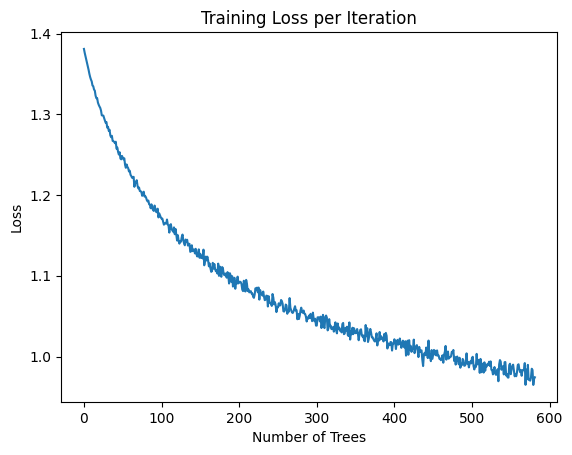

Improvement in last 50 trees: 0.005893


In [5]:
import matplotlib.pyplot as plt

# train_score_ contains the loss at each stage
plt.plot(final_model.train_score_)
plt.title("Training Loss per Iteration")
plt.xlabel("Number of Trees")
plt.ylabel("Loss")
plt.show()

# Quick check: How much did it improve in the last 50 trees?
improvement = final_model.train_score_[-50] - final_model.train_score_[-1]
print(f"Improvement in last 50 trees: {improvement:.6f}")

### Bagging + KNN

In [6]:
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import optuna
import gc

num_classes = len(np.unique(y_train_numeric))
print(f"Number of classes: {num_classes}")

# -------------------------------
# Optuna objective function
# -------------------------------
def objective(trial):

    # -------------------------------
    # Hyperparameter search space
    # -------------------------------
    # Bagging parameters
    n_estimators = trial.suggest_int('n_estimators', 5, 50) # Fewer for KNN as it is slow
    max_samples = trial.suggest_float('max_samples', 0.1, 1.0)
    max_features = trial.suggest_float('max_features', 0.5, 1.0)
    
    # KNN (Base Estimator) parameters
    n_neighbors = trial.suggest_int('n_neighbors', 2, 50)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    p = trial.suggest_int('p', 1, 2) # 1: Manhattan, 2: Euclidean

    param = {
        "n_estimators": n_estimators,
        "max_samples": max_samples,
        "max_features": max_features,
        "random_state": getattr(cfg, "RANDOM_STATE", 42),
        "n_jobs": -1, 
    }
    
    knn_params = {
        "n_neighbors": n_neighbors,
        "weights": weights,
        "p": p,
        "n_jobs": -1,
    }

    # -------------------------------
    # Class weights (Handling Imbalance)
    # -------------------------------
    # KNN doesn't have a 'class_weight' parameter like Trees.
    # We use sample_weight in .fit() instead.
    if cfg.TASK.lower() == "binary":
        cw_dict = {0: 1, 1: 1}
        if getattr(cfg, "IS_UNBALANCE", True):
            weights_cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train_numeric)
            cw_dict = {0: weights_cw[0], 1: weights_cw[1]}
        oof_preds = np.zeros(len(y_train_numeric))
    else:
        classes = np.unique(y_train_numeric)
        weights_cw = compute_class_weight("balanced", classes=classes, y=y_train_numeric)
        cw_dict = {c: w for c, w in zip(classes, weights_cw)}
        oof_preds = np.zeros((len(y_train_numeric), num_classes))

    # -------------------------------
    # Stratified folds
    # -------------------------------
    fold_results = []

    for n_fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train_numeric[train_idx], y_train_numeric[valid_idx]
        
        current_sample_weights = np.array([cw_dict[y] for y in y_tr])

        # Bagging wraps the KNN
        base_knn = KNeighborsClassifier(**knn_params)
        model = BaggingClassifier(
            estimator=base_knn,
            **param
        )

        model.fit(X_tr, y_tr, sample_weight=current_sample_weights)

        # -------------------------------
        # Predictions for OOF
        # -------------------------------
        pred_val = model.predict_proba(X_val)

        if cfg.TASK.lower() == "binary":
            oof_preds[valid_idx] = pred_val[:, 1]
        else:
            oof_preds[valid_idx] = pred_val

        # -------------------------------
        # Evaluate fold
        # -------------------------------
        if cfg.MAXIMIZE_METRIC:
            if cfg.TASK.lower() == "binary":
                fold_score = roc_auc_score(y_val, pred_val[:, 1])
            else:
                fold_score = roc_auc_score(y_val, pred_val, multi_class="ovr")
        else:
            fold_score = log_loss(y_val, pred_val)

        fold_results.append((n_fold, fold_score, model.n_estimators))
        trial.report(fold_score, step=n_fold)

        if trial.should_prune():
            raise optuna.TrialPruned()

        del model, X_tr, X_val, y_tr, y_val, pred_val
        gc.collect()

    gc.collect()

    # -------------------------------
    # True OOF score
    # -------------------------------
    if cfg.MAXIMIZE_METRIC:
        if cfg.TASK.lower() == "binary":
            mean_score = roc_auc_score(y_train_numeric, oof_preds)
        else:
            mean_score = roc_auc_score(y_train_numeric, oof_preds, multi_class="ovr")
    else:
        if cfg.TASK.lower() == "binary":
            oof_probs = np.column_stack([1 - oof_preds, oof_preds])
        else:
            oof_probs = oof_preds
        mean_score = log_loss(y_train_numeric, oof_probs)

    best_iter = int(np.round(np.mean([f[2] for f in fold_results])))

    # -------------------------------
    # Fold report
    # -------------------------------
    metric_label = "AUC" if cfg.MAXIMIZE_METRIC else "LogLoss"
    print("\n" + "*" * 50)
    for fold, score, iter_ in fold_results:
        print(f"Fold {fold:>2d} | {metric_label}: {score:.5f} | Estimators: {iter_:>5d}")
    std_score = np.std([s for _, s, _ in fold_results])
    print(f"\nMean {metric_label}: {mean_score:.5f} ± {std_score:.5f}")
    print("*" * 50 + "\n")

    # -------------------------------
    # Store trial info
    # -------------------------------
    trial.set_user_attr("fold_results", fold_results)
    trial.set_user_attr("best_iteration", best_iter)
    trial.set_user_attr("mean_score", mean_score)
    trial.set_user_attr("params", param)
    trial.set_user_attr("knn_params", knn_params)
    trial.set_user_attr("oof_preds", oof_preds)
    trial.set_user_attr("cw_dict", cw_dict)

    return mean_score

# ... [The remaining logic for training the final model and evaluating stays the same] ...
# ... [Just remember to extract 'knn_params' and 'cw_dict' for the final_model.fit()] ...

Number of classes: 2


In [ ]:
import time
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import gc

# -------------------------------
# Run Optuna optimization
# -------------------------------
start = time.time()
study = run_optuna(objective, cfg, use_median_pruner=False, warmup_steps=2) 
train_time = time.time() - start

# Extract OOF predictions and weight dictionary from the best trial
oof_preds = study.best_trial.user_attrs['oof_preds']
cw_dict = study.best_trial.user_attrs.get("cw_dict")

# -------------------------------
# Train final Bagging + KNN on full training data
# -------------------------------
best_params = study.best_params.copy()
final_knn_params = study.best_trial.user_attrs["knn_params"]

print("\nTraining final Bagging+KNN model on full training data...")

# Reconstruct the base KNN estimator
final_base_estimator = KNeighborsClassifier(**final_knn_params)

final_model = BaggingClassifier(
    estimator=final_base_estimator,
    n_estimators=best_params['n_estimators'],
    max_samples=best_params['max_samples'],
    max_features=best_params['max_features'],
    random_state=getattr(cfg, "RANDOM_STATE", 42),
    n_jobs=-1
)

# Map weights to the full training set for the final fit
final_sample_weights = np.array([cw_dict[y] for y in y_train_numeric])

final_model.fit(X_train, y_train_numeric, sample_weight=final_sample_weights)

# -------------------------------
# Evaluate on training set
# -------------------------------
print("---------------- Train Set --------------------")
pred_train_proba = final_model.predict_proba(X_train)

if cfg.TASK.lower() == "binary":
    y_score_train = pred_train_proba[:, 1]
    y_pred_train_class = (y_score_train >= 0.5).astype(int)
else:
    y_score_train = pred_train_proba
    y_pred_train_class = pred_train_proba.argmax(axis=1)

metrics_df, _ = evaluate_model(
    y_train_numeric,
    y_score_train,
    task=cfg.TASK
)

print(metrics_df)
print("Best mean CV score across all trials:", study.best_value)

# Evaluate OOF
if cfg.TASK.lower() == "binary":
    oof_pred_class = (oof_preds >= 0.5).astype(int)
else:
    oof_pred_class = np.argmax(oof_preds, axis=1)

oof_score = evaluate_metric(
    y_true=y_train_numeric,
    y_input=oof_preds,  # probabilities
    task=TASK,
    kaggle_eval=KAGGLE_EVAL
)
print(f"OOF {KAGGLE_EVAL}: {oof_score:.5f}")

# -------------------------------
# Optional post-processing
# -------------------------------
postprocessing_params = {}
if USE_POSTPROCESSING:
    pp_seeds = [RANDOM_STATE, 2026, 1234, 9999]
    pp_best_params, pp_best_seed, pp_best_score = optimize_postprocessing(
        oof_preds,
        y_train_numeric,
        task=TASK,
        kaggle_eval=KAGGLE_EVAL,
        n_trials=100,
        seeds=pp_seeds
    )

    oof_pred_opt = apply_postprocessing(oof_preds, pp_best_params, task=TASK, return_proba=True)
    oof_pred_class_opt = apply_postprocessing(oof_preds, pp_best_params, task=TASK)
    oof_acc_opt = evaluate_metric(
        y_true=y_train_numeric,
        y_input=oof_pred_opt,
        task=TASK,
        kaggle_eval=KAGGLE_EVAL
    )

    print(f"OOF {KAGGLE_EVAL} after post-processing: {oof_acc_opt:.5f}")
    postprocessing_params = {
        "best_params": pp_best_params,
        "best_seed": pp_best_seed,
        "best_score": pp_best_score,
        "oof_pred_class_opt": oof_pred_class_opt,
        "oof_pred_opt": oof_pred_opt,
        "oof_acc_opt": oof_acc_opt,
        "kaggle_eval": KAGGLE_EVAL
    }

# -------------------------------
# Evaluate on test set
# -------------------------------
pred_test = final_model.predict_proba(X_test)
y_pred_class = (pred_test >= 0.5).astype(int) if cfg.TASK.lower() == "binary" else pred_test.argmax(axis=1)

if X_test is not None and y_test is not None:
    roc_auc_test = roc_auc_score(y_test, pred_test[:, 1]) if cfg.TASK.lower() == "binary" else roc_auc_score(y_test, pred_test, multi_class='ovr')
    logloss_test = log_loss(y_test, pred_test)
    accuracy_test = accuracy_score(y_test, y_pred_class)

    print("\n--- Test set performance ---")
    print(f"Test ROC AUC: {roc_auc_test:.5f}")
    print(f"Test Log Loss: {logloss_test:.5f}")
    print(f"Test Accuracy: {accuracy_test:.5f}")

# -------------------------------
# Experiment Tracking
# -------------------------------
from src.experiment_tracker import ExperimentTracker
tracker = ExperimentTracker()
exp_dir = tracker.run_experiment(
    model_name="bagging_knn", # Updated name
    final_model=final_model,
    X_train=X_train,
    y_train=y_train_numeric,
    X_test=X_test,
    best_params=best_params,
    best_score=study.best_value,
    metrics_df=metrics_df,
    train_time=train_time,
    oof_preds=oof_preds,
    task=TASK,
    postprocessing_params=postprocessing_params,
    use_postprocessing=USE_POSTPROCESSING,
    test_ids=test_ids,
    id_col=ID,
    target_col=TARGET,
    int_to_label=int_to_label,
    sample_submission_path=SUB_PATH,
    submit_proba=SUBMIT_PROBABILITIES
)
gc.collect()